### 1. Data Preparation

In [1]:
import os
from pathlib import Path

In [2]:
def dataset_info(root):
    root = Path(root)

    families = 0
    people = 0
    images = 0

    for family in root.iterdir():
        if family.is_dir():
            families += 1
            for person in family.iterdir():
                if person.is_dir():
                    people += 1
                    images += len(list(person.glob("*.jpg")))

    print(root)
    print("Families:", families)
    print("People   :", people)
    print("Images   :", images)
    print()

dataset_info("data/train")
dataset_info("train-faces")

data\train
Families: 470
People   : 2318
Images   : 12379

train-faces
Families: 786
People   : 3965
Images   : 20080



In [3]:
# Total images if there were no overlap:
# 12379 + 20080 = 32459 images but..

In [4]:
import shutil

# Source folders
source_folders = ["data/train", "train-faces"]

# Destination folder
destination = "combined-train"

# Create destination folder
os.makedirs(destination, exist_ok=True)

# Keep track of copied files
copied = 0
skipped = 0

for source in source_folders:
    # Traverse families
    for family in os.listdir(source):
        family_path = os.path.join(source, family)
        if not os.path.isdir(family_path):
            continue
        # Traverse members
        for member in os.listdir(family_path):
            member_path = os.path.join(family_path, member)

            if not os.path.isdir(member_path):
                continue

            # Destination member folder
            dest_member_path = os.path.join(destination, family, member)
            os.makedirs(dest_member_path, exist_ok=True)
            # Copy images
            for image in os.listdir(member_path):

                if not image.lower().endswith((".jpg", ".jpeg", ".png")):
                    continue

                src_file = os.path.join(member_path, image)
                dst_file = os.path.join(dest_member_path, image)

                # Copy only if filename doesn't already exist
                if not os.path.exists(dst_file):
                    shutil.copy2(src_file, dst_file)
                    copied += 1
                else:
                    skipped += 1

print("\nFinished!")
print(f"Copied : {copied} images")
print(f"Skipped: {skipped} duplicate images")


Finished!
Copied : 0 images
Skipped: 32459 duplicate images


In [5]:
# 23070 unique images

In [6]:
from pathlib import Path

root = Path("combined-train")

families = 0
people = 0
images = 0

for family in root.iterdir():
    if not family.is_dir():
        continue

    families += 1

    for person in family.iterdir():
        if not person.is_dir():
            continue

        people += 1

        images += len(list(person.glob("*.jpg")))

print("Families :", families)
print("People   :", people)
print("Images   :", images)

Families : 890
People   : 4495
Images   : 23070


In [7]:
#No missing values. so  EDA DONE

### Stage 2 : Data Preparation

In [8]:
from pathlib import Path
import os

train_path = Path("combined-train")
person_to_images = {}
for family in os.listdir(train_path):
    family_path = train_path / family
    for person in os.listdir(family_path):
        person_path = family_path / person
        images = []
        for img in os.listdir(person_path):
            images.append(person_path / img)

        # Store only if the person has at least one image
        if images:
            person_to_images[f"{family}/{person}"] = images

In [9]:
#verifying
print("Total Persons:", len(person_to_images))  #people with zero images after filtering 
sample_person = next(iter(person_to_images))
print(sample_person)
person_to_images[sample_person][0] 

Total Persons: 4458
F0001/MID1


WindowsPath('combined-train/F0001/MID1/P00001_face2.jpg')

In [10]:
# 4495 (all person folders)
# -
# 4458 (persons with images)
# --------------------------
# 37

In [11]:
#Now will generate positive pairs notice:-
# Yes, positive PERSON pairs are already given.
# No, 
# positive IMAGE pairs are not given.

In [12]:
import pandas as pd
relationships = pd.read_csv("train_relationships.csv")
print("Total Relationships:", len(relationships))
relationships.head()

Total Relationships: 3598


,p1,p2
0,F0002/MID1,F0002/MID3
1,F0002/MID2,F0002/MID3
2,F0005/MID1,F0005/MID2
3,F0005/MID3,F0005/MID2
4,F0009/MID1,F0009/MID4


In [13]:
positive_pairs = []
used_pairs = set()

for _, row in relationships.iterrows():

    person1 = row["p1"]
    person2 = row["p2"]

    # Skip if either person has no images
    if person1 not in person_to_images or person2 not in person_to_images:
        continue

    images1 = person_to_images[person1]
    images2 = person_to_images[person2]

    for img1 in images1:
        for img2 in images2:

            # Prevent duplicate image pairs
            pair = tuple(sorted((str(img1), str(img2))))

            if pair in used_pairs:
                continue

            used_pairs.add(pair)
            positive_pairs.append((img1, img2, 1))

print("Total Positive Image Pairs:", len(positive_pairs))

Total Positive Image Pairs: 165179


In [14]:
skipped = 0
for _, row in relationships.iterrows():
    if row["p1"] not in person_to_images or row["p2"] not in person_to_images:
        skipped += 1
print("Skipped Relationships:", skipped)
#could not be converted into image pairs because at least one person was missing from the dataset.

Skipped Relationships: 236


In [15]:
# treating like train set

### now negative pairs


In [16]:
# So choose only ONE random image?
# one random to many can generate multiples negative..

In [17]:
import random

negative_pairs = []
used_pairs = set()

all_people = list(person_to_images.keys())

# Keep negatives equal to positives
target = len(positive_pairs)

while len(negative_pairs) < target:

    # Randomly choose two people
    person1 = random.choice(all_people)
    person2 = random.choice(all_people)

    # Skip same person
    if person1 == person2:
        continue

    # Skip same family
    if person1.split("/")[0] == person2.split("/")[0]:
        continue

    # (Safety check)
    if len(person_to_images[person1]) == 0 or len(person_to_images[person2]) == 0:
        continue

    # Random image from each person
    img1 = random.choice(person_to_images[person1])
    img2 = random.choice(person_to_images[person2])

    # Treat (A,B) and (B,A) as the same pair
    pair = tuple(sorted((str(img1), str(img2))))

    if pair in used_pairs:
        continue

    used_pairs.add(pair)
    negative_pairs.append((img1, img2, 0))

print("Total Negative Image Pairs:", len(negative_pairs))

Total Negative Image Pairs: 165179


In [18]:
print("Positive:", len(positive_pairs))
print("Negative:", len(negative_pairs))
print("Total Dataset:", len(positive_pairs) + len(negative_pairs))

Positive: 165179
Negative: 165179
Total Dataset: 330358


In [19]:
all_pairs = positive_pairs + negative_pairs
random.shuffle(all_pairs)
print("Total Samples:", len(all_pairs))

Total Samples: 330358


In [20]:
from sklearn.model_selection import train_test_split
train_pairs, val_pairs = train_test_split(
    all_pairs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)
print("Training Samples:", len(train_pairs))
print("Validation Samples:", len(val_pairs))

Training Samples: 264286
Validation Samples: 66072


In [21]:
# why exact same as train dataset:-
print("Relationships:", len(relationships))
usable = 0
for _, row in relationships.iterrows():
    if row["p1"] in person_to_images and row["p2"] in person_to_images:
        usable += 1
print("Usable:", usable)

Relationships: 3598
Usable: 3362


In [22]:
relationship_people = set()
for _, row in relationships.iterrows():
    relationship_people.add(row["p1"])
    relationship_people.add(row["p2"])

extra_people = set(person_to_images.keys()) - relationship_people
print("People not used in relationships:", len(extra_people))

People not used in relationships: 2142


In [23]:
train_pos = sum(label for _, _, label in train_pairs)
train_neg = len(train_pairs) - train_pos

val_pos = sum(label for _, _, label in val_pairs)
val_neg = len(val_pairs) - val_pos

print("\nTraining Set")    
print("Positive:", train_pos)
print("Negative:", train_neg)

print("\nValidation Set")
print("Positive:", val_pos)
print("Negative:", val_neg)


Training Set
Positive: 131981
Negative: 132305

Validation Set
Positive: 33198
Negative: 32874


In [24]:
# Difference is only 144 out of 205k samples (0.07%).
# Excellent.

In [25]:
from torch.utils.data import Dataset
from PIL import Image

class KinshipDataset(Dataset):

    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

In [26]:
# (Path,Path,Label) to (Image Tensor,Image Tensor,Label)

In [27]:
# Stage 3 (continued): Image Transform
# Now we tell PyTorch how every image should be prepared before entering the CNN

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


In [28]:
# Stage 4 : Create Dataset Objects
train_dataset = KinshipDataset(train_pairs,transform=train_transform)
val_dataset = KinshipDataset(val_pairs,transform=val_transform)

In [29]:
#verifying 
print(len(train_dataset))
print(len(val_dataset))

264286
66072


In [30]:
#teesting on one sample
img1, img2, label = train_dataset[0]
print(img1.shape)
print(img2.shape)
print(label)                      # Stage 4 ✔ Image Transform

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
0


### DataLoader

In [31]:
from torch.utils.data import DataLoader
#Train Loader
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
# Why shuffle=True only for training?
# Model should see data in different order every epoch.

# Validation 
# We only measure accuracy.
# Order doesn't matter.

In [32]:
print(len(train_loader))  #205724/64=3215
print(len(val_loader))    #51432/64=804

4130
1033


In [33]:
from torchvision import models
import torch.nn as nn

# Load pretrained ResNet50
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove the final classification layer
resnet.fc = nn.Identity()

In [34]:
import torch
dummy = torch.randn(1, 3, 224, 224).cuda()
resnet = resnet.cuda()
with torch.no_grad():
    embedding = resnet(dummy)
print(embedding.shape)

torch.Size([1, 512])


In [35]:
import torch
import torch.nn as nn
from torchvision import models

class SiameseNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        # Pretrained ResNet18 backbone
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # Remove ImageNet classifier
        self.backbone.fc = nn.Identity()

        # Similarity classifier
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, 1)
        )

    def forward_once(self, x):
        return self.backbone(x)

    def forward(self, img1, img2):

        emb1 = self.forward_once(img1)
        emb2 = self.forward_once(img2)

        # Absolute difference between embeddings
        diff = torch.abs(emb1 - emb2)

        output = self.classifier(diff)

        return output

In [36]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseNetwork().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

EPOCHS = 15

In [37]:
 #verifying 
img1 = torch.randn(4,3,224,224).to(device)
img2 = torch.randn(4,3,224,224).to(device)
output = model(img1,img2)

print(output)

tensor([[ 0.0302],
        [-0.1798],
        [-0.0067],
        [ 0.1892]], device='cuda:0', grad_fn=<AddmmBackward0>)


### Stage 9: Training Setup,

In [38]:
import torch

def validate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for img1, img2, labels in dataloader:

            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(img1, img2)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

In [39]:
#Step 2 : Create checkpoint folder
import os
os.makedirs("checkpoints_combined_resnet18", exist_ok=True)

In [40]:
import os
import torch

start_epoch = 0
best_acc = 0.0

checkpoint_path = "checkpoints_combined_resnet18/best_model.pth"

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_acc = checkpoint["best_acc"]

    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    val_accuracies = checkpoint["val_accuracies"]

    print(f"✅ Resuming from Epoch {start_epoch}")
    print(f"Best Accuracy: {best_acc*100:.2f}%")

else:
    print("Starting Fresh Training")

✅ Resuming from Epoch 12
Best Accuracy: 96.05%


In [41]:
from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

C:\Users\rishu\AppData\Local\Temp\ipykernel_25644\434963958.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [42]:
from tqdm import tqdm
import torch

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(start_epoch, EPOCHS):

    model.train()
    running_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for img1, img2, labels in progress_bar:

        img1 = img1.to(device, non_blocking=True)
        img2 = img2.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast():
            outputs = model(img1, img2)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.1e}"
        )

    train_loss = running_loss / len(train_loader)

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )
    scheduler.step(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_acc": best_acc,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "val_accuracies": val_accuracies,
        }, "checkpoints_combined_resnet18/best_model.pth")
        print("✅ Best Model Saved")

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_acc": best_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
    }, "checkpoints_combined_resnet18/best_model.pth")

    print("-"*60)
    print(f"Epoch      : {epoch+1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc*100:.2f}%")
    print(f"Best Acc   : {best_acc*100:.2f}%")
    print("💾 Latest Checkpoint Saved\n")

Epoch 13/15:   0%|          | 0/4130 [00:00<?, ?it/s]C:\Users\rishu\AppData\Local\Temp\ipykernel_25644\1096721306.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 13/15: 100%|██████████| 4130/4130 [57:19<00:00,  1.20it/s, loss=0.0345, lr=1.0e-04]  


✅ Best Model Saved
------------------------------------------------------------
Epoch      : 13/15
Train Loss : 0.0645
Val Loss   : 0.0922
Val Acc    : 96.47%
Best Acc   : 96.47%
💾 Latest Checkpoint Saved



Epoch 14/15: 100%|██████████| 4130/4130 [48:02<00:00,  1.43it/s, loss=0.0511, lr=1.0e-04] 


✅ Best Model Saved
------------------------------------------------------------
Epoch      : 14/15
Train Loss : 0.0483
Val Loss   : 0.0884
Val Acc    : 96.73%
Best Acc   : 96.73%
💾 Latest Checkpoint Saved



Epoch 15/15: 100%|██████████| 4130/4130 [51:40<00:00,  1.33it/s, loss=0.0564, lr=1.0e-04]  


------------------------------------------------------------
Epoch      : 15/15
Train Loss : 0.0412
Val Loss   : 0.0985
Val Acc    : 96.35%
Best Acc   : 96.73%
💾 Latest Checkpoint Saved



### Evaluating

In [43]:
# 1. Imports
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [44]:
# 2. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [45]:
# 3. Image Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [46]:
# 4. Read CSV & Create Pairs
all_pairs
train_pairs, val_pairs = train_test_split(
    all_pairs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [47]:
# Dataset
train_dataset = KinshipDataset(train_pairs, transform)
val_dataset = KinshipDataset(val_pairs, transform)

In [49]:
checkpoint = torch.load(
    "checkpoints_combined_resnet18/best_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("✅ Combined ResNet18 Model Loaded Successfully")

✅ Combined ResNet18 Model Loaded Successfully


In [50]:
#9. Evaluate on Validation Set
all_labels = []
all_preds = []
all_probs = []

from tqdm import tqdm

with torch.no_grad():
    for img1, img2, labels in tqdm(val_loader):
        img1 = img1.to(device)
        img2 = img2.to(device)

        outputs = model(img1, img2)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())    

100%|██████████| 1033/1033 [04:03<00:00,  4.24it/s]


In [52]:
all_labels = np.array(all_labels)
all_preds = np.array(all_preds).flatten()
all_probs = np.array(all_probs).flatten()

print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall   :", recall_score(all_labels, all_preds))
print("F1 Score :", f1_score(all_labels, all_preds))
print("ROC AUC  :", roc_auc_score(all_labels, all_probs))

print("\nConfusion Matrix")
print(confusion_matrix(all_labels, all_preds))

Accuracy : 0.963539774791137
Precision: 0.9813037361263092
Recall   : 0.9454485209952407
F1 Score : 0.9630425110841784
ROC AUC  : 0.995779604104876

Confusion Matrix
[[32276   598]
 [ 1811 31387]]


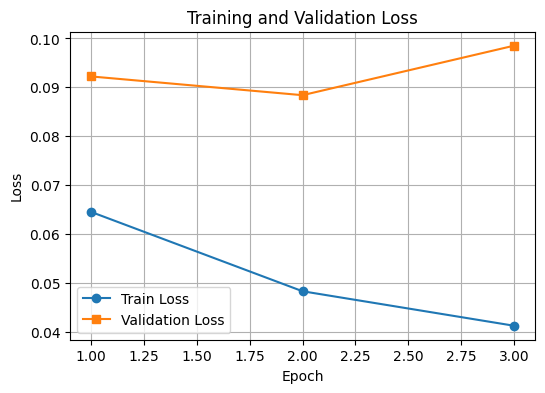

In [55]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

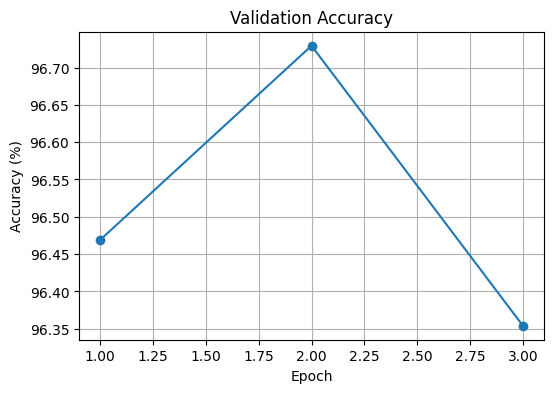

In [57]:
plt.figure(figsize=(6,4))

plt.plot(
    epochs,
    [acc*100 for acc in val_accuracies],
    marker='o'
)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

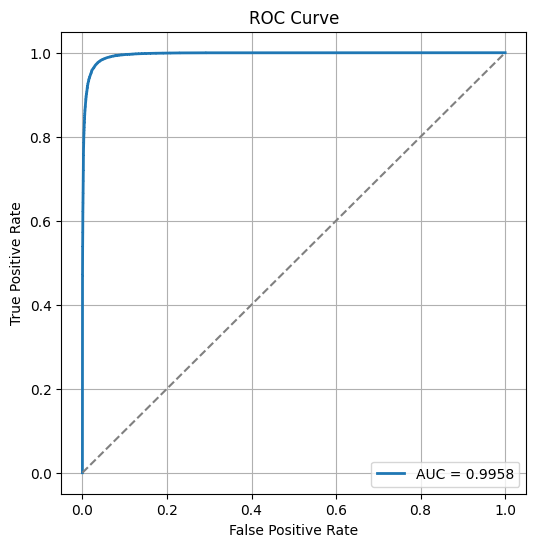

In [58]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1], '--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

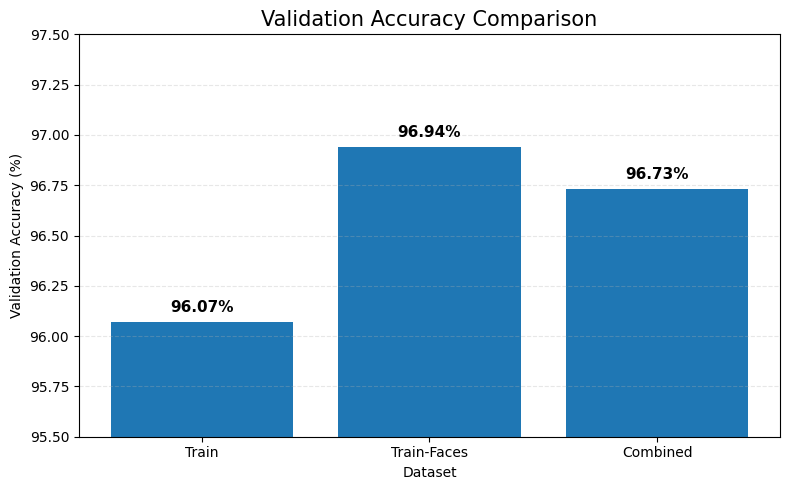

In [60]:
import matplotlib.pyplot as plt

models = [
    "Train",
    "Train-Faces",
    "Combined"
]

val_accuracy = [
    96.07,   # Train
    96.94,   # Train-Faces
    96.73    # Combined
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, val_accuracy)

# Show values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Validation Accuracy Comparison", fontsize=15)
plt.xlabel("Dataset")
plt.ylabel("Validation Accuracy (%)")
plt.ylim(95.5, 97.5)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()